In [1]:
# typical Python libraries
import numpy as np
import matplotlib.pyplot as plt

# Libraries to read data from internet
import requests

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_norm

# Hugging Face libraries
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup, get_cosine_schedule_with_warmup
#

In [2]:
# Set device to CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Download tokenizer and the model from Hugging Face

In [3]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

# Import texts

In [4]:
# Import texts for "Through the Looking Glass" and "Edgar Allen" Poe texts
text = requests.get('https://www.gutenberg.org/cache/epub/11/pg11.txt').text
aliceTokens = torch.tensor(tokenizer.encode(text), dtype=torch.long)

# Import texts for Edgar Allen Poe"
text = requests.get('https://www.gutenberg.org/cache/epub/2148/pg2148.txt').text
eapTokens =torch.tensor(tokenizer.encode(text),dtype=torch.long)

print(f'{'Number of tokens for "Alice in Wonderland"':42}: {len(aliceTokens):>7,}')
print(f'{'Number of tokens for "Edgar Allen Poe"':42}: {len(eapTokens):>7,}')

Token indices sequence length is longer than the specified maximum sequence length for this model (40923 > 512). Running this sequence through the model will result in indexing errors


Number of tokens for "Alice in Wonderland":  40,923
Number of tokens for "Edgar Allen Poe"    : 130,193


# Create a classifer model based on BERT

In [5]:
class BertForBinaryClassification(nn.Module):
  def __init__(self, num_labels=2):
    super(BertForBinaryClassification, self).__init__()

    # Load the pre-trained BERT model.
    self.bert = BertModel.from_pretrained('bert-base-uncased')

    # classification head that converts the 768-d pooled output into 2 final outputs.
    self.classifier = nn.Linear(768,2)
    self.dropout = nn.Dropout(self.bert.embeddings.dropout.p) # Use the same dropout as BERT's embedding layer (10%)

    # initialize the weights and biases
    nn.init.xavier_uniform_(self.classifier.weight)
    nn.init.zeros_(self.classifier.bias)


  def forward(self, input_ids, attention_mask=None, token_type_ids=None):

    # forward pass through the downloaded (pretrained) BERT
    outputs = self.bert(
      input_ids      = input_ids,
      attention_mask = attention_mask,
      token_type_ids = token_type_ids)

    # extract the pooled output and apply dropout
    pooled_output = self.dropout( outputs.pooler_output )

    # final push through the classification layer.
    logits = self.classifier(pooled_output)
    return logits

In [110]:
# create an instance of the model and test
model = BertForBinaryClassification()
model.to(device);

In [111]:
# Test the model with random numbers for a single run with a bacth of 32 samples
batch_size = 32
seq_length = 256

ixA = torch.randint(low=0, high=len(aliceTokens)-seq_length, size=(batch_size//2,1))
ixB = torch.randint(low=0, high=len(eapTokens)-seq_length, size=(batch_size//2,1))

x1 = aliceTokens[ixA + torch.arange(seq_length)]
x2 = eapTokens[ixB + torch.arange(seq_length)]

X = torch.cat((x1,x2),dim=0).to(device)

labels = torch.tensor([0]*(batch_size//2) + [1]*(batch_size//2)).to(device)

logits = model(X)
pred_labels = torch.argmax(logits,dim=1)

accuracy = 100*(pred_labels == labels).float().mean()
print(f'Accuracy: {accuracy:.2f}%')

loss = nn.CrossEntropyLoss()(logits,labels)
print(f'Loss: {loss.item():.2f}')

Accuracy: 56.25%
Loss: 0.80


# Train the model

In [112]:
# optimizer and loss functions
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-6, weight_decay=0.01)
loss_fn = nn.CrossEntropyLoss()

In [116]:
num_runs = 150
seq_length = 256

loss_run = np.zeros(num_runs)
acc_run = np.zeros(num_runs)

for run in range(num_runs):
  ixA = torch.randint(low=0, high=len(aliceTokens)-seq_length, size=(batch_size//2,1))
  ixB = torch.randint(low=0, high=len(eapTokens)-seq_length, size=(batch_size//2,1))

  x1 = aliceTokens[ixA + torch.arange(seq_length)]
  x2 = eapTokens[ixB + torch.arange(seq_length)]

  X = torch.cat((x1,x2),dim=0).to(device)

  labels = torch.tensor([0]*(batch_size//2) + [1]*(batch_size//2)).to(device)

  # Forward pass

  logits = model(X)
  pred_labels = torch.argmax(logits,dim=1)

  accuracy = 100*(pred_labels == labels).float().mean()

  acc_run[run] = accuracy.item()

  loss = loss_fn(logits,labels)
  loss_run[run] = loss.item()

  # Back propagation
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if run % 10 == 0:
    print(f'{run+1}/{num_runs}: Loss: {loss:.3f}| Accuracy: {accuracy:.2f}%')

1/150: Loss: 0.184| Accuracy: 96.88%
11/150: Loss: 0.110| Accuracy: 96.88%
21/150: Loss: 0.210| Accuracy: 93.75%
31/150: Loss: 0.118| Accuracy: 96.88%
41/150: Loss: 0.168| Accuracy: 93.75%
51/150: Loss: 0.088| Accuracy: 96.88%
61/150: Loss: 0.170| Accuracy: 93.75%
71/150: Loss: 0.064| Accuracy: 100.00%
81/150: Loss: 0.094| Accuracy: 96.88%
91/150: Loss: 0.060| Accuracy: 100.00%
101/150: Loss: 0.054| Accuracy: 100.00%
111/150: Loss: 0.160| Accuracy: 93.75%
121/150: Loss: 0.069| Accuracy: 100.00%
131/150: Loss: 0.034| Accuracy: 100.00%
141/150: Loss: 0.026| Accuracy: 100.00%


In [103]:
def mean_smooth_with_padding(arr, kernel_size):
    if kernel_size <= 0:
        raise ValueError("kernel_size must be positive")
    if len(arr) < kernel_size:
        raise ValueError("Array length must be >= kernel size")

    kernel = np.ones(kernel_size) / kernel_size
    return np.convolve(arr, kernel, mode="same")


In [152]:
kernel_size = 5
loss_mean_smoothed_with_padding = mean_smooth_with_padding(loss_run, kernel_size)
acc_mean_smoothed_with_padding = mean_smooth_with_padding(acc_run, kernel_size)

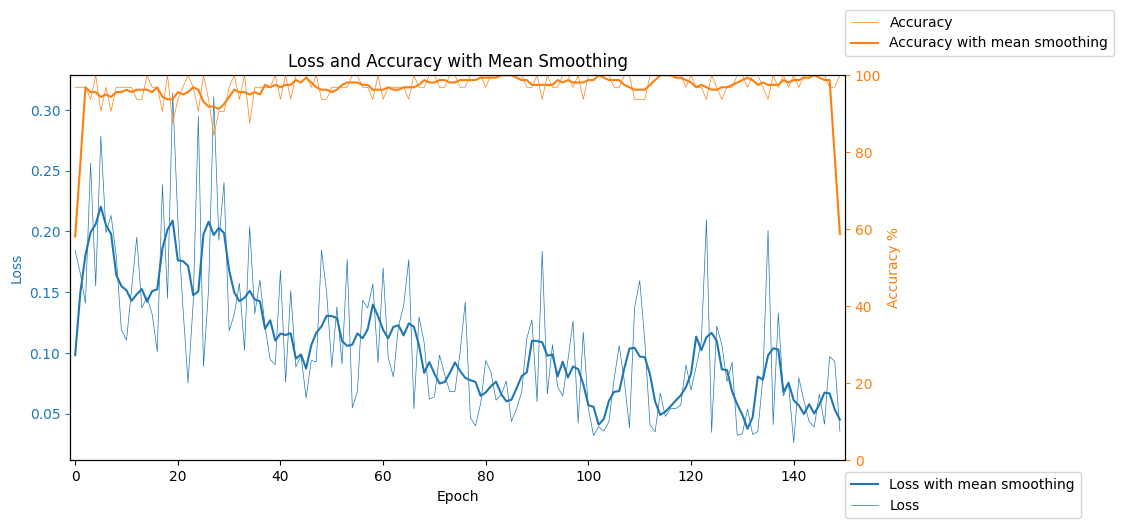

In [164]:
# Visualize
_, axs = plt.subplots(1,figsize=(10,5))
axs.plot(loss_mean_smoothed_with_padding, 'C0',label='Loss with mean smoothing')
axs.plot(loss_run, 'C0',label='Loss', linewidth=.5)
axs.tick_params(axis='y',color='C0',labelcolor='C0')

axs.set_xlabel('Epoch')
axs.set_xlim([-1,num_runs])

axs.set_ylabel('Loss', color='C0')
axs.legend(loc=[1,-.15])


# Create secondary axis
axs2 = axs.twinx()
axs2.plot(acc_run, 'C1', label='Accuracy', linewidth=.5)
axs2.plot(acc_mean_smoothed_with_padding, 'C1', label='Accuracy with mean smoothing')


axs2.set_ylabel('Accuracy %', color='C1')
axs2.set_ylim([0,100])
axs2.tick_params(axis='y',color='C1',labelcolor='C1')


axs2.legend(loc=[1,1.05])

plt.title('Loss and Accuracy with Mean Smoothing')
plt.show()

# Save the model

In [132]:
torch.save(model.state_dict(), 'bert-classification-model.pt')

In [134]:
acc_mean_smoothed_with_padding

array([48.4375, 57.5   , 67.1875, 76.25  , 85.9375, 95.625 , 95.625 ,
       95.625 , 95.3125, 95.3125, 95.3125, 95.9375, 95.9375, 95.9375,
       96.25  , 95.3125, 95.    , 95.    , 95.625 , 95.9375, 95.    ,
       95.3125, 95.    , 94.375 , 93.4375, 93.75  , 94.0625, 94.375 ,
       93.75  , 94.0625, 93.75  , 93.4375, 93.75  , 95.    , 95.625 ,
       96.5625, 96.25  , 96.25  , 96.25  , 96.25  , 97.5   , 97.8125,
       97.8125, 98.125 , 97.8125, 97.1875, 97.5   , 97.1875, 97.5   ,
       97.1875, 97.1875, 97.1875, 97.1875, 96.875 , 96.875 , 97.5   ,
       97.1875, 97.1875, 97.1875, 97.1875, 96.875 , 96.25  , 96.5625,
       96.5625, 96.875 , 96.875 , 97.5   , 97.5   , 97.5   , 97.8125,
       98.125 , 98.4375, 98.125 , 98.4375, 98.75  , 98.75  , 98.4375,
       98.75  , 99.0625, 99.0625, 99.0625, 99.375 , 99.6875, 99.6875,
       99.375 , 99.0625, 99.375 , 98.75  , 98.75  , 98.4375, 98.125 ,
       98.125 , 98.125 , 97.8125, 98.125 , 97.8125, 97.8125, 98.4375,
       98.4375, 98.7

In [135]:
acc_run

array([ 96.875,  96.875,  96.875,  93.75 , 100.   ,  90.625,  96.875,
        90.625,  96.875,  96.875,  96.875,  96.875,  93.75 ,  93.75 ,
       100.   ,  96.875,  96.875,  90.625, 100.   ,  87.5  ,  93.75 ,
        96.875, 100.   ,  96.875,  90.625, 100.   ,  93.75 ,  84.375,
        90.625,  90.625,  96.875, 100.   ,  93.75 , 100.   ,  87.5  ,
        96.875,  96.875,  96.875,  96.875, 100.   ,  93.75 , 100.   ,
        93.75 , 100.   , 100.   , 100.   ,  96.875, 100.   ,  93.75 ,
        93.75 ,  96.875,  96.875,  96.875,  96.875, 100.   , 100.   ,
        96.875,  96.875,  93.75 , 100.   ,  93.75 ,  96.875,  96.875,
        96.875,  96.875,  93.75 , 100.   ,  96.875,  96.875, 100.   ,
       100.   ,  96.875,  96.875, 100.   , 100.   ,  96.875,  96.875,
       100.   , 100.   , 100.   ,  96.875, 100.   , 100.   , 100.   ,
       100.   , 100.   , 100.   , 100.   ,  96.875,  96.875, 100.   ,
        93.75 , 100.   ,  96.875,  96.875, 100.   , 100.   ,  96.875,
       100.   ,  93.